# Example-09: Linear invariants

In [1]:
# Import

import numpy
import pandas
import torch
import yaml

import sys
sys.path.append('..')

from harmonica.util import mod
from harmonica.statistics import mean, variance
from harmonica.statistics import weighted_mean, weighted_variance
from harmonica.window import Window
from harmonica.data import Data
from harmonica.frequency import Frequency
from harmonica.filter import Filter
from harmonica.decomposition import Decomposition
from harmonica.model import Model
from harmonica.table import Table

import matplotlib.pyplot as plt

torch.set_printoptions(precision=12, sci_mode=True)
print(torch.cuda.is_available())

True


In [2]:
# Set data type and device

dtype = torch.float64
device = torch.device('cpu')

In [3]:
# In this example uncoupled and coupled linear invariants (actions) are computed

In [4]:
# Generate test trajectories for uncoupled model

# Set uncoupled model

model = Model(path='../config_uncoupled.yaml', model='uncoupled', dtype=dtype, device=device)

# Set errors

model.make_error(1.0E-3, 1.0E-3, length=0.01)

# Compute transport

model.make_transport(error=True, exact=False)

# Compute twiss (not used in generation of trajectories)

model.make_twiss()
print(model.is_stable)

# Set initial condition

state = torch.tensor([0.002, 0.0, 0.002, 0.0], dtype=dtype, device=device)

# Set number of iterations

length = 2**12

# Generate trajectories

trajectory =  model.make_trajectory(state, length, error=True, transport=True)
print(trajectory.shape)

True
torch.Size([59, 4096, 4])


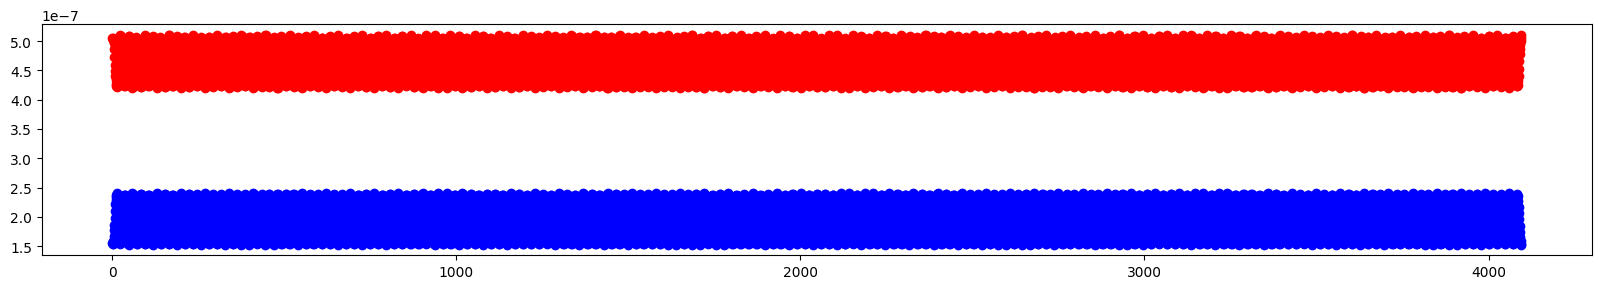

X: mean=4.64696225e-07, std=3.04563983e-08
Y: mean=1.95923311e-07, std=3.04177139e-08


In [5]:
# Compute uncoupled invariant

from harmonica.parameterization import invariant_uncoupled

index = 0
jx, jy = invariant_uncoupled(model.out_normal[index], trajectory[index])

plt.figure(figsize=(20, 3))
plt.scatter(range(4096), jx, color='red')
plt.scatter(range(4096), jy, color='blue')
plt.show()

print(f'X: mean={jx.mean().item():12.9}, std={jx.std().item():12.9}')
print(f'Y: mean={jy.mean().item():12.9}, std={jy.std().item():12.9}')

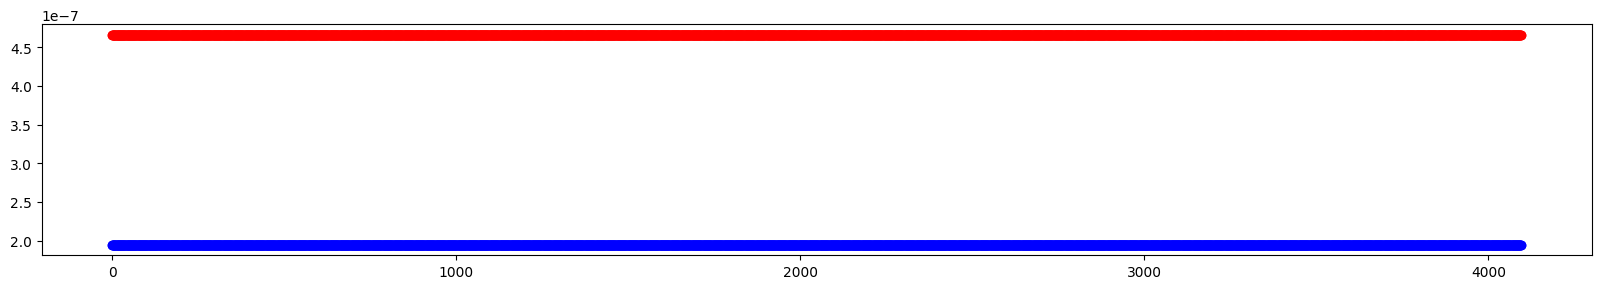

X: mean=4.66059167e-07, std=7.9799983e-19
Y: mean=1.94550842e-07, std=2.14541883e-19


In [6]:
# Compute coupled invariant (same as uncoupled in this case)

from harmonica.parameterization import invariant_coupled

index = 0
jx, jy = invariant_coupled(model.out_normal[index], trajectory[index])

plt.figure(figsize=(20, 3))
plt.scatter(range(4096), jx, color='red')
plt.scatter(range(4096), jy, color='blue')
plt.show()

print(f'X: mean={jx.mean().item():12.9}, std={jx.std().item():12.9}')
print(f'Y: mean={jy.mean().item():12.9}, std={jy.std().item():12.9}')

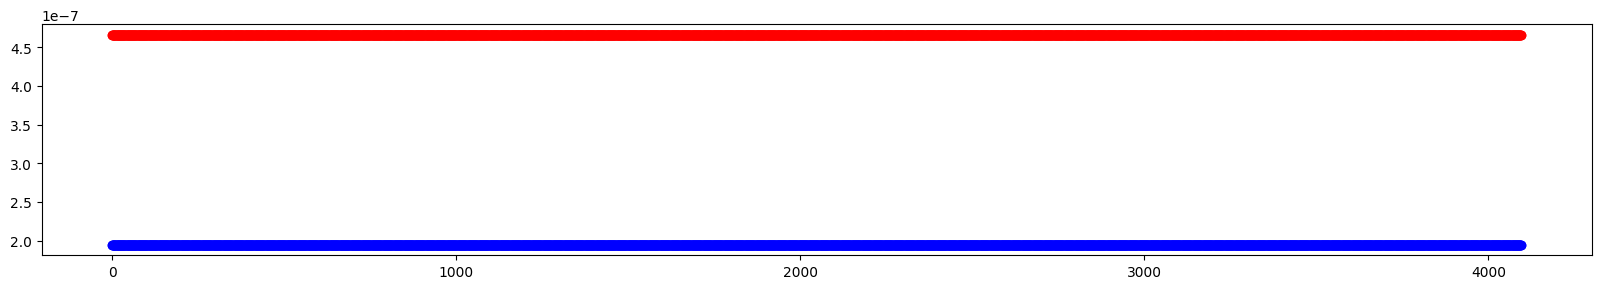

X: mean=4.66059167e-07, std=7.97992265e-19
Y: mean=1.94550842e-07, std=2.14544772e-19


In [7]:
# Both invariant_uncoupled & invariant_coupled use elements of the input normalization matrix to compute invariants
# Normalization matrix can be used directly

from harmonica.parameterization import invariant

index = 0
jx, jy = invariant(model.out_normal[index], trajectory[index])

plt.figure(figsize=(20, 3))
plt.scatter(range(4096), jx, color='red')
plt.scatter(range(4096), jy, color='blue')
plt.show()

print(f'X: mean={jx.mean().item():12.9}, std={jx.std().item():12.9}')
print(f'Y: mean={jy.mean().item():12.9}, std={jy.std().item():12.9}')